In [1]:
#загрузим библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import joblib
import os

In [2]:
#загрузим датасет
df = pd.read_csv("UCI_Credit_Card.csv")

In [3]:
#анализ датасета
print("Shape:", df.shape)
display(df.head())
display(df.sample(5, random_state=42))
print(df.info())

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
2308,2309,30000.0,1,2,2,25,0,0,0,0,...,12580.0,13716.0,14828.0,1500.0,2000.0,1500.0,1500.0,1500.0,2000.0,0
22404,22405,150000.0,2,1,2,26,0,0,0,0,...,101581.0,77741.0,77264.0,4486.0,4235.0,3161.0,2647.0,2669.0,2669.0,0
23397,23398,70000.0,2,3,1,32,0,0,0,0,...,69753.0,70111.0,70212.0,2431.0,3112.0,3000.0,2438.0,2500.0,2554.0,0
25058,25059,130000.0,1,3,2,49,0,0,0,0,...,16898.0,11236.0,6944.0,1610.0,1808.0,7014.0,27.0,7011.0,4408.0,0
2664,2665,50000.0,2,2,2,36,0,0,0,0,...,19574.0,20295.0,19439.0,2000.0,1500.0,1000.0,1800.0,0.0,1000.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Данный датасет содержит 30 000 строк и 24 признака, признаки целочисленные или числа с точкой, целевая переменная — default.payment.next.month

In [4]:
#пропущенные данные
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


Пропущенных данных нет

In [5]:
#повторы
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


Повторяющихся данных нет

In [6]:
target_col = "default.payment.next.month"
print("Target distribution:")
print(df[target_col].value_counts())
print("\nTarget proportions:")
print(df[target_col].value_counts(normalize=True))

Target distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target proportions:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [8]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


ID — идентификатор , его можно убрать; SEX, EDUCATION, MARRIAGE — категориальные/кодововые признаки; LIMIT_BAL, AGE, PAY_0 ... PAY_6, BILL_AMT1 ... BILL_AMT6, PAY_AMT1 ... PAY_AMT6 — числовые признаки

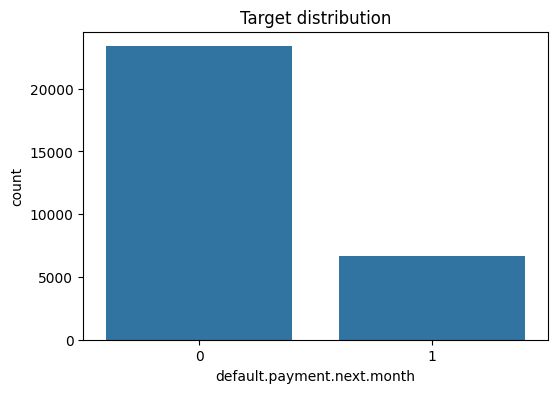

In [9]:
#визуализируем
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Target distribution")
plt.show()

В датасете гораздо больше клиентов без дефолта, чем с ним, поэтому при обучении модели стоит ориентироваться не только на общую точность, но и на показатели для класса «дефолт». При этом для прогноза особенно ценны данные о прошлых просрочках платежей - они важнее обычных анкетных сведений

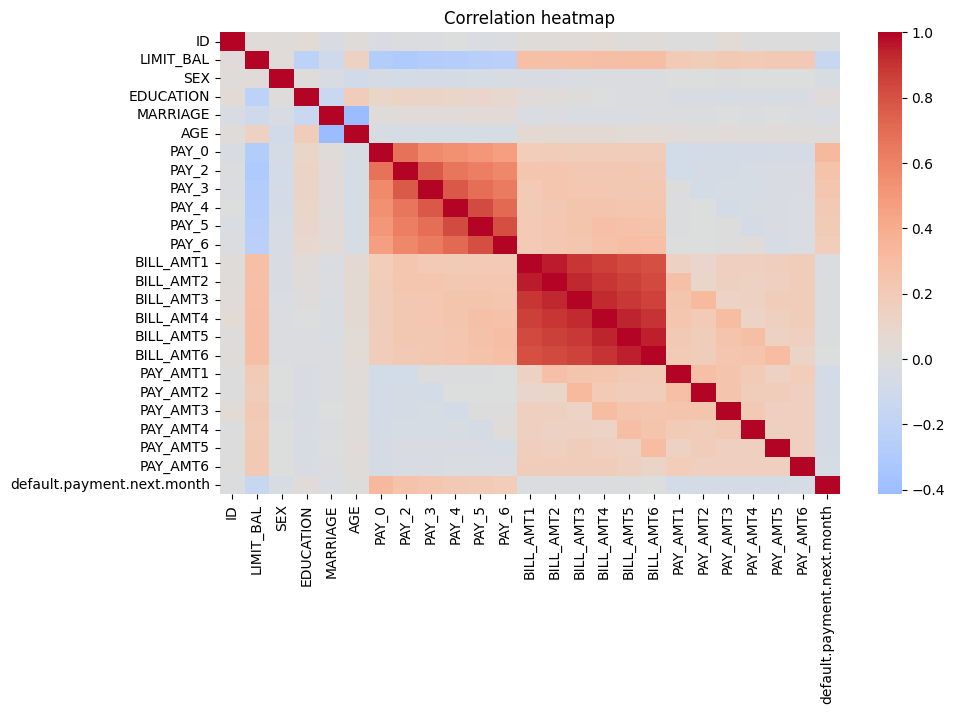

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

In [11]:
#подготовка признаков перед обучением
X = df.drop(columns=["ID", target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


In [12]:
#разделим на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(24000, 23) (6000, 23)
default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64


In [13]:
#oбучение LogisticRegression
num_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'SEX',
                                                   'EDUCATION', 'MARRIAGE',
                                                   'AGE', 'PAY_0', 'PAY_2',
                                                   'PAY_3', 'PAY_4', 'PAY_5',
                                                   'PAY_6', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [14]:
#метрики
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6796666666666666
F1: 0.461322869955157
Precision: 0.36724676483712626
Recall: 0.6201959306706858
ROC AUC: 0.7081149369197677

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

Confusion matrix:
 [[3255 1418]
 [ 504  823]]


Модель работает средне: она находит большую часть клиентов с дефолтом, но часто ошибается и помечает надёжных клиентов как рискованных. Есть запас для улучшения - можно настроить порог срабатывания и лучше учесть дисбаланс классов.

In [15]:
#сохраним модель
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/credit_default_lr.joblib")
print("Model saved to models/credit_default_lr.joblib")

Model saved to models/credit_default_lr.joblib


In [16]:
#функция загрузки модели
def load_model(path="models/credit_default_lr.joblib"):
    return joblib.load(path)

In [17]:
#функция инференса
def predict_default(model, input_dict, threshold=0.5):
    input_df = pd.DataFrame([input_dict])
    proba = model.predict_proba(input_df)[:, 1][0]
    pred = int(proba >= threshold)
    return {
        "prediction": pred,
        "probability": float(proba)
    }

In [18]:
#проверка
loaded_model = load_model()

sample = {
    "LIMIT_BAL": 200000,
    "SEX": 2,
    "EDUCATION": 2,
    "MARRIAGE": 1,
    "AGE": 35,
    "PAY_0": 0,
    "PAY_2": 0,
    "PAY_3": 0,
    "PAY_4": 0,
    "PAY_5": 0,
    "PAY_6": 0,
    "BILL_AMT1": 50000,
    "BILL_AMT2": 48000,
    "BILL_AMT3": 47000,
    "BILL_AMT4": 45000,
    "BILL_AMT5": 43000,
    "BILL_AMT6": 42000,
    "PAY_AMT1": 3000,
    "PAY_AMT2": 3000,
    "PAY_AMT3": 2000,
    "PAY_AMT4": 2000,
    "PAY_AMT5": 1000,
    "PAY_AMT6": 1000
}

predict_default(loaded_model, sample)

{'prediction': 0, 'probability': 0.4736084378720057}

Для примера модель предсказала класс 0, то есть отсутствие дефолта, с вероятностью около 0.47. Это значение близко к порогу 0.5, модель не уверена в своём решении и находится «на границе» между двумя классами.

Такой результат удобно интерпретировать как пограничный случай: если важнее не пропустить потенциальный дефолт, можно понизить порог классификации, чтобы модель чаще относила клиентов к рисковой группе. Если же важно уменьшить число ложных отказов, порог можно поднять.